In [5]:
# --- Core helpers and detector backends ---

import os, glob, time
import numpy as np
import cv2

# ---------- I/O ----------
def save_bin(path, img):
    """Save RGB uint8 image to raw .bin (H*W*3 bytes)."""
    assert img.dtype == np.uint8 and img.ndim == 3 and img.shape[2] == 3
    os.makedirs(os.path.dirname(path), exist_ok=True)
    img.tofile(path)

# ---------- Preprocessing ----------
def clahe_normalize_rgb(img_rgb):
    """A2-inspired: CLAHE on Y channel (illumination normalization)."""
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    y_eq = clahe.apply(y)
    return cv2.cvtColor(cv2.merge([y_eq,cr,cb]), cv2.COLOR_YCrCb2RGB)

def gaussian_denoise(img_rgb):
    """Light denoise to improve SNR."""
    return cv2.GaussianBlur(img_rgb, (3,3), 0)

def resize_pad(img, size):
    """Letterbox to keep aspect, then center-pad to (W,H)."""
    w,h = size
    ih, iw = img.shape[:2]
    scale = min(w/iw, h/ih)
    nw, nh = int(iw*scale), int(ih*scale)
    resized = cv2.resize(img, (nw,nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((h,w,3), dtype=np.uint8)
    x0, y0 = (w-nw)//2, (h-nh)//2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    return canvas

# ---------- Safe crop + guarded prep ----------
def safe_crop(img, box, min_size=10):
    """Clamp bbox to image, ensure positive area; return None if invalid/small."""
    if box is None or img is None:
        return None
    x1, y1, x2, y2 = box
    H, W = img.shape[:2]
    x1 = max(0, min(int(x1), W-1)); x2 = max(0, min(int(x2), W))
    y1 = max(0, min(int(y1), H-1)); y2 = max(0, min(int(y2), H))
    if x2 <= x1 or y2 <= y1:
        return None
    roi = img[y1:y2, x1:x2]
    if roi.shape[0] < min_size or roi.shape[1] < min_size:
        return None
    return roi

def prep_roi(img):
    """Apply CLAHE + Gaussian; return None if input invalid."""
    if img is None or img.size == 0:
        return None
    try:
        img = clahe_normalize_rgb(img)
        img = gaussian_denoise(img)
        return img
    except Exception:
        return None

# ---------- Landmark-based detector (previous working version) ----------
_HAS_MEDIAPIPE, _HAS_DLIB = False, False
try:
    import mediapipe as mp
    _HAS_MEDIAPIPE = True
except Exception:
    pass
try:
    import dlib
    _HAS_DLIB = True
except Exception:
    pass

class LandmarkDetector:
    def __init__(self, backend="auto"):
        self.backend = backend
        if backend == "auto":
            if _HAS_MEDIAPIPE:
                self.backend = "mediapipe"
            elif _HAS_DLIB:
                self.backend = "dlib"
            else:
                self.backend = "haar"

        if self.backend == "mediapipe":
            self.mp_face = mp.solutions.face_mesh.FaceMesh(
                static_image_mode=False,
                max_num_faces=1,
                refine_landmarks=True,
                min_detection_confidence=0.5,
                min_tracking_confidence=0.5
            )
        elif self.backend == "dlib":
            self.detector = dlib.get_frontal_face_detector()
            sp_path = os.getenv("DLIB_LANDMARK_PATH", "shape_predictor_68_face_landmarks.dat")
            if not os.path.exists(sp_path):
                raise RuntimeError("Need dlib landmark predictor file. Set DLIB_LANDMARK_PATH.")
            self.shape_predictor = dlib.shape_predictor(sp_path)
        else:
            # Haar fallback
            self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
            self.eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

    def detect(self, frame_rgb):
        H, W = frame_rgb.shape[:2]

        # --- MediaPipe branch ---
        if self.backend == "mediapipe":
            res = self.mp_face.process(frame_rgb)
            if not res.multi_face_landmarks:
                return None
            lm = res.multi_face_landmarks[0]
            W, H = frame_rgb.shape[1], frame_rgb.shape[0]
        
            # Outer eye corners
            left_eye_outer = lm.landmark[33]
            right_eye_outer = lm.landmark[263]
            lx, ly = int(left_eye_outer.x * W), int(left_eye_outer.y * H)
            rx, ry = int(right_eye_outer.x * W), int(right_eye_outer.y * H)
            IOD = rx - lx
        
            # Eyebrow top (use min y from eyebrow landmarks)
            L_EB_IDX = list(range(70, 106))
            R_EB_IDX = list(range(336, 362))
            eb_pts = np.array([(int(lm.landmark[i].x*W), int(lm.landmark[i].y*H)) for i in L_EB_IDX + R_EB_IDX])
            eb_top_y = eb_pts[:,1].min()
        
            # Forehead box
            fh_x1 = lx
            fh_x2 = rx
            fh_y1 = int(eb_top_y - 0.25 * IOD)
            fh_y2 = int(fh_y1 + 0.5 * IOD)
            forehead = (fh_x1, fh_y1, fh_x2, fh_y2)
        
            # Eyes as before
            LIDX = [33,246,161,160,159,158,157,173]
            RIDX = [263,466,388,387,386,385,384,398]
            lpts = np.array([(int(lm.landmark[i].x*W), int(lm.landmark[i].y*H)) for i in LIDX])
            rpts = np.array([(int(lm.landmark[i].x*W), int(lm.landmark[i].y*H)) for i in RIDX])
            lx1,ly1 = lpts.min(0); lx2,ly2 = lpts.max(0)
            rx1,ry1 = rpts.min(0); rx2,ry2 = rpts.max(0)
        
            return {"left_eye":(int(lx1),int(ly1),int(lx2),int(ly2)),
                    "right_eye":(int(rx1),int(ry1),int(rx2),int(ry2)),
                    "forehead":forehead}


        # --- dlib branch ---
        if self.backend == "dlib":
            gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
            rects = self.detector(gray,1)
            if not rects:
                return None
            rect = rects[0]
            shape = self.shape_predictor(gray, rect)
            pts = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)])
        
            # Outer eye corners
            lx, ly = pts[36]
            rx, ry = pts[45]
            IOD = rx - lx
        
            # Eyebrow top
            eb_top_y = pts[17:27][:,1].min()
        
            # Forehead box
            fh_x1 = lx
            fh_x2 = rx
            fh_y1 = int(eb_top_y - 0.25 * IOD)
            fh_y2 = int(fh_y1 + 0.5 * IOD)
            forehead = (fh_x1, fh_y1, fh_x2, fh_y2)
        
            l = pts[36:42]; r = pts[42:48]
            lx1,ly1 = l.min(0); lx2,ly2 = l.max(0)
            rx1,ry1 = r.min(0); rx2,ry2 = r.max(0)
        
            return {"left_eye":(int(lx1),int(ly1),int(lx2),int(ly2)),
                    "right_eye":(int(rx1),int(ry1),int(rx2),int(ry2)),
                    "forehead":forehead}



        # --- Haar fallback ---
                # ...existing code...
        x,y,w,h = faces[0]
        IOD = w // 2
        fh_x1 = x + w//4
        fh_x2 = x + 3*w//4
        fh_y1 = y + h//8 - int(0.25 * IOD)
        fh_y2 = fh_y1 + int(0.5 * IOD)
        fh = (fh_x1, fh_y1, fh_x2, fh_y2)
        return {"forehead":fh,
                "left_eye":(x, y+h//4, x+w//2, y+h//2),
                "right_eye":(x+w//2, y+h//4, x+w, y+h//2)}
        # ...existing code...



In [6]:
# === Cell 2: process_video_fast_robust with 90° CW rotation on read ===

def _pre_enhance_for_detection(rgb):
    try:
        lut = np.array([((i/255.0) ** (1/1.2))*255 for i in range(256)]).astype("uint8")
        rgb = cv2.LUT(rgb, lut)
        ycrcb = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
        y, cr, cb = cv2.split(ycrcb)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        y = clahe.apply(y)
        rgb = cv2.cvtColor(cv2.merge([y,cr,cb]), cv2.COLOR_YCrCb2RGB)
    except Exception:
        pass
    return rgb

def _rotate_image_and_boxes(img, angle_deg, boxes=None):
    if angle_deg == 0:
        return img, boxes
    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle_deg, 1.0)
    rot = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    if boxes is None:
        return rot, None
    new_boxes = {}
    for k,(x1,y1,x2,y2) in boxes.items():
        pts = np.array([[x1,y1,1],[x2,y1,1],[x2,y2,1],[x1,y2,1]], dtype=np.float32).T
        rp = (M @ pts).T
        rx1, ry1 = np.min(rp[:,0]), np.min(rp[:,1])
        rx2, ry2 = np.max(rp[:,0]), np.max(rp[:,1])
        new_boxes[k] = (int(round(rx1)), int(round(ry1)), int(round(rx2)), int(round(ry2)))
    return rot, new_boxes

def _haar_face_heuristic(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(gray, 1.2, 4)
    if len(faces) == 0: 
        return None
    x,y,w,h = faces[0]
    fh = (x, y, x+w, y + max(1, h//5))
    le = (x, y + h//4, x + w//2, y + h//2)
    re = (x + w//2, y + h//4, x + w, y + h//2)
    return {"forehead": fh, "left_eye": le, "right_eye": re}

def process_video_fast_robust(path, out_dir="out", base="sample", backend="auto", size=(128,64),
                              timestamps_s=(5,10,20,30,45,52),
                              detect_height=720, rotations=(-15, 0, 15),
                              save_qc=True):
    import os, cv2
    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(path, cv2.CAP_FFMPEG)
    if not cap.isOpened():
        cap = cv2.VideoCapture(path)

    # NOTE: rotate grabbed frame 90° clockwise so sideways .mov becomes upright
    def read_at_time(tsec, jitter_ms=(0,100,-100,200,-200)):
        for j in jitter_ms:
            cap.set(cv2.CAP_PROP_POS_MSEC, max(0.0, tsec*1000.0 + j))
            ok, bgr = cap.read()
            if not ok or bgr is None:
                continue
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.rotate(rgb, cv2.ROTATE_90_CLOCKWISE)  # <--- rotation fix
            return rgb
        return None

    last_exc = None
    for t in timestamps_s:
        frame_full = read_at_time(t)
        if frame_full is None:
            continue

        Hf, Wf = frame_full.shape[:2]
        for ang in rotations:
            det_rgb = _pre_enhance_for_detection(frame_full)
            if detect_height and det_rgb.shape[0] > detect_height:
                s = detect_height / float(det_rgb.shape[0])
                det_rgb = cv2.resize(det_rgb, (int(det_rgb.shape[1]*s), detect_height), interpolation=cv2.INTER_AREA)
            else:
                s = 1.0

            det_rgb_rot, _ = _rotate_image_and_boxes(det_rgb, ang, None)
            try_chain = [backend] if backend != "auto" else ["mediapipe","dlib","haar"]
            bboxes = None

            for be in try_chain:
                try:
                    if be == "haar":
                        bboxes = _haar_face_heuristic(det_rgb_rot)
                        if bboxes is None: 
                            continue
                    else:
                        det = LandmarkDetector(be)
                        bboxes = det.detect(det_rgb_rot)

                    if not bboxes:
                        continue

                    det_rgb_unrot, bboxes_unrot = _rotate_image_and_boxes(det_rgb_rot, -ang, bboxes)

                    if s != 1.0:
                        s_inv = 1.0 / s
                        bboxes_full = {}
                        for k,(x1,y1,x2,y2) in bboxes_unrot.items():
                            x1 = int(round(x1*s_inv)); y1 = int(round(y1*s_inv))
                            x2 = int(round(x2*s_inv)); y2 = int(round(y2*s_inv))
                            x1 = max(0,min(x1,Wf-1)); x2 = max(0,min(x2,Wf))
                            y1 = max(0,min(y1,Hf-1)); y2 = max(0,min(y2,Hf))
                            bboxes_full[k] = (x1,y1,x2,y2)
                    else:
                        bboxes_full = bboxes_unrot

                    def make_bin(key):
                        raw = safe_crop(frame_full, bboxes_full.get(key), min_size=12)
                        raw = prep_roi(raw)
                        return resize_pad(raw, size) if raw is not None else None

                    roi_f = make_bin("forehead")
                    roi_l = make_bin("left_eye")
                    roi_r = make_bin("right_eye")
                    if roi_f is None or roi_l is None or roi_r is None:
                        continue

                    outF = os.path.join(out_dir, f"{base}_forehead.bin")
                    outL = os.path.join(out_dir, f"{base}_left_eye.bin")
                    outR = os.path.join(out_dir, f"{base}_right_eye.bin")
                    save_bin(outF, roi_f); save_bin(outL, roi_l); save_bin(outR, roi_r)

                    if save_qc:
                        qc = frame_full.copy()
                        for k,(x1,y1,x2,y2) in bboxes_full.items():
                            cv2.rectangle(qc,(x1,y1),(x2,y2),(0,255,0),2)
                            cv2.putText(qc,k,(x1,max(0,y1-6)),cv2.FONT_HERSHEY_SIMPLEX,0.55,(0,255,0),1,cv2.LINE_AA)
                        cv2.imwrite(os.path.join(out_dir, f"{base}_qc.png"), cv2.cvtColor(qc, cv2.COLOR_RGB2BGR))

                    return {"forehead": outF, "left_eye": outL, "right_eye": outR}

                except Exception as e:
                    last_exc = e
                    continue

    raise RuntimeError(f"ROI detection failed after robust search. Last error: {last_exc}")


In [7]:
VIDEOS_DIR = "videos"
OUT_DIR    = "out_rois"
SIZE       = (128, 64)

video_paths = []
for ext in ("*.mov"):
    video_paths.extend(glob.glob(os.path.join(VIDEOS_DIR, ext)))
video_paths = sorted(set(video_paths))

results, failures = {}, []
print(f"Found {len(video_paths)} videos")

for i, vp in enumerate(video_paths, 1):
    base = os.path.splitext(os.path.basename(vp))[0]
    print(f"[{i}/{len(video_paths)}] Processing: {base}")
    t0 = time.time()
    try:
        paths = process_video_fast_robust(
            vp, out_dir=OUT_DIR, base=base, backend="auto", size=SIZE,
            timestamps_s=(5,10,20,30,45,52), detect_height=720,
            rotations=(-15,0,15), save_qc=True
        )
        results[base] = paths
        print(f"  OK in {time.time()-t0:.2f}s -> {paths}")
    except Exception as e:
        failures.append((base, str(e)))
        print(f"  FAIL in {time.time()-t0:.2f}s: {e}")

print("\nSuccess:", len(results), "Failures:", len(failures))
if failures:
    print("Failed files:")
    for b, msg in failures:
        print(" -", b, ":", msg)


Found 6 videos
[1/6] Processing: .
  FAIL in 0.23s: ROI detection failed after robust search. Last error: None
[2/6] Processing: 1-004
  OK in 1.06s -> {'forehead': 'out_rois\\1-004_forehead.bin', 'left_eye': 'out_rois\\1-004_left_eye.bin', 'right_eye': 'out_rois\\1-004_right_eye.bin'}
[3/6] Processing: 10-003
  OK in 1.06s -> {'forehead': 'out_rois\\10-003_forehead.bin', 'left_eye': 'out_rois\\10-003_left_eye.bin', 'right_eye': 'out_rois\\10-003_right_eye.bin'}
[4/6] Processing: 29-005
  OK in 1.10s -> {'forehead': 'out_rois\\29-005_forehead.bin', 'left_eye': 'out_rois\\29-005_left_eye.bin', 'right_eye': 'out_rois\\29-005_right_eye.bin'}
[5/6] Processing: 5-001
  OK in 1.10s -> {'forehead': 'out_rois\\5-001_forehead.bin', 'left_eye': 'out_rois\\5-001_left_eye.bin', 'right_eye': 'out_rois\\5-001_right_eye.bin'}
[6/6] Processing: 6-002
  OK in 1.20s -> {'forehead': 'out_rois\\6-002_forehead.bin', 'left_eye': 'out_rois\\6-002_left_eye.bin', 'right_eye': 'out_rois\\6-002_right_eye.bin'}



[1-004] Overlay saved -> out_rois\1-004_overlay.png


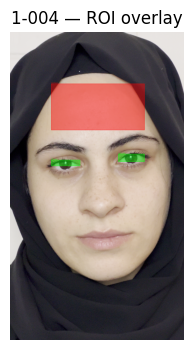

[10-003] Overlay saved -> out_rois\10-003_overlay.png


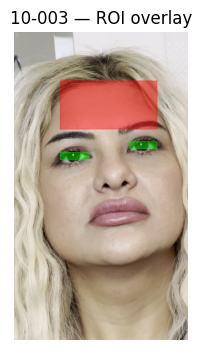

[29-005] Overlay saved -> out_rois\29-005_overlay.png


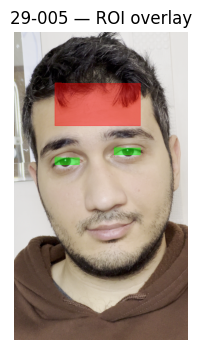

[5-001] Overlay saved -> out_rois\5-001_overlay.png


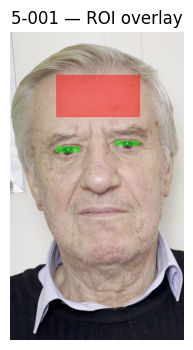

[6-002] Overlay saved -> out_rois\6-002_overlay.png


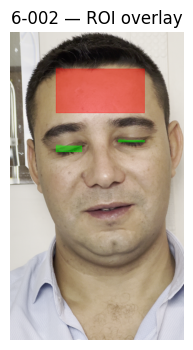

In [8]:
# === QC overlays: filled, semi-transparent (eyes=green, forehead=red), .mov only, rotated upright ===
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import cv2

VIDEOS_DIR = "videos"
OUT_DIR    = "out_rois"
BACKEND    = "auto"          # or "mediapipe"
TIMESTAMPS = (5, 10, 20, 30, 45, 52)
DETECT_HEIGHT = 720
ALPHA = 0.45  # fill transparency

# collect only .mov files
video_paths = []
for ext in ("*.mov","*.MOV"):
    video_paths.extend(glob.glob(os.path.join(VIDEOS_DIR, ext)))
video_paths = sorted(set(video_paths))

def read_at_time(cap, tsec, jitter_ms=(0,100,-100,200,-200)):
    for j in jitter_ms:
        cap.set(cv2.CAP_PROP_POS_MSEC, max(0.0, tsec*1000.0 + j))
        ok, bgr = cap.read()
        if ok and bgr is not None:
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            rgb = cv2.rotate(rgb, cv2.ROTATE_90_CLOCKWISE)  # <--- rotation fix
            return rgb
    return None

def detect_bboxes_on_frame(frame_rgb, backend="auto", detect_height=720):
    Hf, Wf = frame_rgb.shape[:2]
    if detect_height and Hf > detect_height:
        s = detect_height / float(Hf)
        det_rgb = cv2.resize(frame_rgb, (int(Wf*s), detect_height), interpolation=cv2.INTER_AREA)
    else:
        s = 1.0
        det_rgb = frame_rgb

    chain = [backend] if backend != "auto" else ["mediapipe", "dlib", "haar"]
    for be in chain:
        det = LandmarkDetector(be)
        b = det.detect(det_rgb)
        if not b:
            continue
        if s != 1.0:
            s_inv = 1.0 / s
            b_full = {}
            for k,(x1,y1,x2,y2) in b.items():
                x1 = int(round(x1*s_inv)); y1 = int(round(y1*s_inv))
                x2 = int(round(x2*s_inv)); y2 = int(round(y2*s_inv))
                x1 = max(0, min(x1, Wf-1)); x2 = max(0, min(x2, Wf))
                y1 = max(0, min(y1, Hf-1)); y2 = max(0, min(y2, Hf))
                if x2 <= x1: x2 = min(Wf, x1+1)
                if y2 <= y1: y2 = min(Hf, y1+1)
                b_full[k] = (x1,y1,x2,y2)
        else:
            b_full = b
        return b_full
    return None

COL_FOREHEAD = (255, 0, 0)   # red (RGB)
COL_EYE      = (0, 255, 0)   # green

def fill_rect(overlay, box, color, alpha=0.45):
    H, W = overlay.shape[:2]
    if box is None: return
    x1,y1,x2,y2 = box
    x1 = max(0, min(x1, W)); x2 = max(0, min(x2, W))
    y1 = max(0, min(y1, H)); y2 = max(0, min(y2, H))
    if x2 <= x1 or y2 <= y1: return
    roi = overlay[y1:y2, x1:x2].astype(np.float32)
    overlay[y1:y2, x1:x2] = (1-ALPHA)*roi + ALPHA*np.array(color, dtype=np.float32)

for vp in video_paths:
    base = os.path.splitext(os.path.basename(vp))[0]
    cap = cv2.VideoCapture(vp, cv2.CAP_FFMPEG)
    if not cap.isOpened():
        cap = cv2.VideoCapture(vp)

    frame = None; boxes = None
    for t in TIMESTAMPS:
        frame = read_at_time(cap, t)
        if frame is None: 
            continue
        boxes = detect_bboxes_on_frame(frame, backend=BACKEND, detect_height=DETECT_HEIGHT)
        if boxes:
            break
    cap.release()

    if frame is None or not boxes:
        print(f"[{base}] No detection for overlay.")
        continue

    vis = frame.copy()
    # filled masks
    fill_rect(vis, boxes.get("forehead"), COL_FOREHEAD, ALPHA)
    fill_rect(vis, boxes.get("left_eye"), COL_EYE, ALPHA)
    fill_rect(vis, boxes.get("right_eye"), COL_EYE, ALPHA)
    # thin borders + labels
    for key, col in [("forehead", COL_FOREHEAD), ("left_eye", COL_EYE), ("right_eye", COL_EYE)]:
        if key in boxes:
            x1,y1,x2,y2 = boxes[key]
            cv2.rectangle(vis, (x1,y1), (x2,y2), col, 2)
            cv2.putText(vis, key, (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 1, cv2.LINE_AA)

    out_png = os.path.join(OUT_DIR, f"{base}_overlay.png")
    cv2.imwrite(out_png, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
    print(f"[{base}] Overlay saved -> {out_png}")

    plt.figure(figsize=(6,4))
    plt.imshow(vis); plt.title(f"{base} — ROI overlay"); plt.axis("off")
    plt.show()
